- There are many hidden information in the date and time

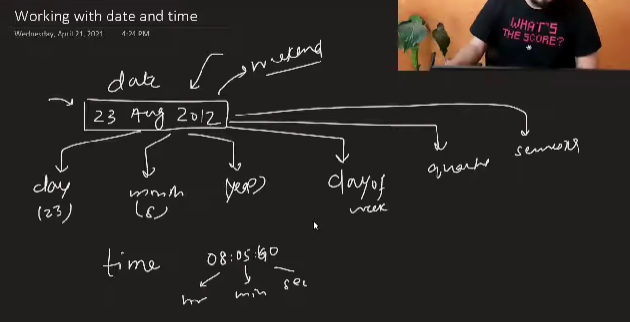

In [1]:
import numpy as np
import pandas as pd

In [2]:
date = pd.read_csv('orders.csv')
time = pd.read_csv('messages.csv')

In [3]:
date.head()

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157
2,2018-10-23,1859,25,1
3,2019-08-17,7292,25,1
4,2019-01-06,4344,25,3


In [4]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [5]:
date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1000 non-null   object
 1   product_id  1000 non-null   int64 
 2   city_id     1000 non-null   int64 
 3   orders      1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


In [6]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


- we we import date and time in pd dataframe, it will be imported as an object (string)
- we can use pd.to_datetime() to convert it to datetime format to work with it further

# Working with Dates

In [7]:
# Converting to datetime datatype
date['date'] = pd.to_datetime(date['date'])

In [8]:
date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1000 non-null   datetime64[ns]
 1   product_id  1000 non-null   int64         
 2   city_id     1000 non-null   int64         
 3   orders      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 31.4 KB


#### 1. Extract year

In [9]:
date['date_year'] = date['date'].dt.year # dt: datetime

date.sample(5)

,date,product_id,city_id,orders,date_year
349,2018-09-02,5819,25,4,2018
607,2019-05-27,3685,0,1,2019
315,2018-11-10,3345,13,23,2018
274,2019-01-22,5618,21,3,2019
51,2019-08-12,6344,26,1,2019


#### 2. Extract Month

In [10]:
date['date_month_no'] = date['date'].dt.month

date.head()

,date,product_id,city_id,orders,date_year,date_month_no
0,2019-12-10,5628,25,3,2019,12
1,2018-08-15,3646,14,157,2018,8
2,2018-10-23,1859,25,1,2018,10
3,2019-08-17,7292,25,1,2019,8
4,2019-01-06,4344,25,3,2019,1


In [11]:
date['date_month_name'] = date['date'].dt.month_name()

date.head()

,date,product_id,city_id,orders,date_year,date_month_no,date_month_name
0,2019-12-10,5628,25,3,2019,12,December
1,2018-08-15,3646,14,157,2018,8,August
2,2018-10-23,1859,25,1,2018,10,October
3,2019-08-17,7292,25,1,2019,8,August
4,2019-01-06,4344,25,3,2019,1,January


#### Extract Days

In [12]:
date['date_day'] = date['date'].dt.day

date.head()

,date,product_id,city_id,orders,date_year,date_month_no,date_month_name,date_day
0,2019-12-10,5628,25,3,2019,12,December,10
1,2018-08-15,3646,14,157,2018,8,August,15
2,2018-10-23,1859,25,1,2018,10,October,23
3,2019-08-17,7292,25,1,2019,8,August,17
4,2019-01-06,4344,25,3,2019,1,January,6


In [13]:
# day of week : Uss particular date week ke kis din par aata hai
date['date_dow'] = date['date'].dt.dayofweek

date.head()


,date,product_id,city_id,orders,date_year,date_month_no,date_month_name,date_day,date_dow
0,2019-12-10,5628,25,3,2019,12,December,10,1
1,2018-08-15,3646,14,157,2018,8,August,15,2
2,2018-10-23,1859,25,1,2018,10,October,23,1
3,2019-08-17,7292,25,1,2019,8,August,17,5
4,2019-01-06,4344,25,3,2019,1,January,6,6


In [15]:
# day of week - name

date['date_dow_name'] = date['date'].dt.day_name()

date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name
0,2019-12-10,2019,12,December,10,1,Tuesday
1,2018-08-15,2018,8,August,15,2,Wednesday
2,2018-10-23,2018,10,October,23,1,Tuesday
3,2019-08-17,2019,8,August,17,5,Saturday
4,2019-01-06,2019,1,January,6,6,Sunday


In [16]:
# is weekend?

date['date_is_weekend'] = np.where(date['date_dow_name'].isin(['Sunday', 'Saturday']), 1,0)

date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend
0,2019-12-10,2019,12,December,10,1,Tuesday,0
1,2018-08-15,2018,8,August,15,2,Wednesday,0
2,2018-10-23,2018,10,October,23,1,Tuesday,0
3,2019-08-17,2019,8,August,17,5,Saturday,1
4,2019-01-06,2019,1,January,6,6,Sunday,1


#### Extract week of the year

In [19]:
date['date_week'] = date['date'].dt.isocalendar().week

date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43
3,2019-08-17,2019,8,August,17,5,Saturday,1,33
4,2019-01-06,2019,1,January,6,6,Sunday,1,1


#### Extract Quarter

In [20]:
date['quarter'] = date['date'].dt.quarter

date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quarter
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1


#### Extract Semester

In [21]:
date['semester'] = np.where(date['quarter'].isin([1,2]), 1, 2)

date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quarter,semester
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4,2
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3,2
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4,2
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3,2
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1,1


#### Extract Time elapsed between dates

In [22]:
import datetime

today = datetime.datetime.today()

today

datetime.datetime(2026, 3, 5, 22, 4, 0, 256777)

In [23]:
today - date['date']

0     2277 days 22:04:00.256777
1     2759 days 22:04:00.256777
2     2690 days 22:04:00.256777
3     2392 days 22:04:00.256777
4     2615 days 22:04:00.256777
                 ...           
995   2705 days 22:04:00.256777
996   2646 days 22:04:00.256777
997   2494 days 22:04:00.256777
998   2559 days 22:04:00.256777
999   2333 days 22:04:00.256777
Name: date, Length: 1000, dtype: timedelta64[ns]

In [24]:
(today - date['date']).dt.days

0      2277
1      2759
2      2690
3      2392
4      2615
       ... 
995    2705
996    2646
997    2494
998    2559
999    2333
Name: date, Length: 1000, dtype: int64

In [26]:
# Months passed (integer months)
months_passed = (today.year - date['date'].dt.year) * 12 + (today.month - date['date'].dt.month)
months_passed

0      75
1      91
2      89
3      79
4      86
       ..
995    89
996    87
997    82
998    84
999    77
Name: date, Length: 1000, dtype: int32

# Working with Time

In [27]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [28]:
# Converting to datetime datatype
time['date'] = pd.to_datetime(time['date'])

In [29]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[ns]
 1   msg     1000 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 15.8+ KB


In [30]:
time['hour'] = time['date'].dt.hour
time['min'] = time['date'].dt.minute
time['sec'] = time['date'].dt.second

time.head()

,date,msg,hour,min,sec
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


#### Extract Time part (as the column contains both date and time, we can extract the time part)

In [31]:
time['time'] = time['date'].dt.time

time.head()

,date,msg,hour,min,sec,time
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0,00:50:00
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0,23:40:00
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0,00:21:00
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0,00:31:00
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0,23:11:00


#### Time difference

In [32]:
today - time['date']

0     4463 days 21:14:00.256777
1     4327 days 22:24:00.256777
2     4813 days 21:43:00.256777
3     4115 days 21:33:00.256777
4     4512 days 22:53:00.256777
                 ...           
995   5102 days 21:14:00.256777
996   4423 days 22:50:00.256777
997   4888 days 22:27:00.256777
998   5004 days 22:30:00.256777
999   4276 days 22:39:00.256777
Name: date, Length: 1000, dtype: timedelta64[ns]

In [33]:
# in seconds

(today - time['date'])/np.timedelta64(1,'s')

0      3.856796e+08
1      3.739334e+08
2      4.159214e+08
3      3.556136e+08
4      3.899192e+08
           ...     
995    4.408892e+08
996    3.822294e+08
997    4.224040e+08
998    4.324266e+08
999    3.695279e+08
Name: date, Length: 1000, dtype: float64

In [34]:
# in minutes

(today - time['date'])/np.timedelta64(1,'m')

0      6.427994e+06
1      6.232224e+06
2      6.932023e+06
3      5.926893e+06
4      6.498653e+06
           ...     
995    7.348154e+06
996    6.370490e+06
997    7.040067e+06
998    7.207110e+06
999    6.158799e+06
Name: date, Length: 1000, dtype: float64

In [35]:
# in hours

(today - time['date'])/np.timedelta64(1,'h')

0      107133.233405
1      103870.400071
2      115533.716738
3       98781.550071
4      108310.883405
           ...      
995    122469.233405
996    106174.833405
997    117334.450071
998    120118.500071
999    102646.650071
Name: date, Length: 1000, dtype: float64